#  Install Required Packages

In [1]:
# Core libraries
!pip install numpy pandas scipy scikit-learn networkx tqdm imbalanced-learn

# PyTorch (CUDA 12.4)
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

# PyTorch Geometric
!pip install torch-geometric

# torch-scatter via pre-built wheel (avoids build-from-source issues)
import torch
TORCH = torch.__version__.split('+')[0]
CUDA = 'cu124'
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv \
    -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Looking in indexes: https://download.pytorch.org/whl/cu124



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#  Import Libraries

In [1]:
import copy
import itertools
import warnings
import os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import networkx as nx

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch_geometric.nn import GCNConv, MessagePassing
from torch_geometric.utils import add_self_loops

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
from sklearn.metrics.pairwise import cosine_similarity
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import softmax
import numpy as np
from imblearn.over_sampling import SMOTE

from tqdm import tqdm, trange

import matplotlib.pyplot as plt

print('Imports OK')
print(f'PyTorch  : {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

Imports OK
PyTorch  : 2.6.0+cu124
CUDA available: True


#  Parse Raw Data and Create Kaggle Format Dataset

In [2]:
# Parse the raw semicolon-delimited file
raw_df = pd.read_csv('LUSCexpfile.csv')
df = raw_df.iloc[:, 0].str.split(';', expand=True)
labels_raw = df.iloc[0, 1:]          # first row = sample labels
genes = df.iloc[1:, 0]               # first col = gene names
expression = df.iloc[1:, 1:]
expression.index = genes
expression = expression.apply(pd.to_numeric, errors='coerce')
expression_t = expression.T          # samples × genes

# Build binary labels
labels_clean = (
    labels_raw
    .astype(str)
    .str.lower()
    .str.strip()
    .replace('none', pd.NA)
)
binary_labels = labels_clean.apply(
    lambda x: 1 if isinstance(x, str) and 'tumor' in x
         else 0 if isinstance(x, str) and 'normal' in x
         else pd.NA
)
valid_idx = binary_labels.notna()
binary_labels = binary_labels[valid_idx].astype(int)
expression_t = expression_t.loc[valid_idx]
expression_t['label'] = binary_labels.values
expression_t.insert(0, 'sample_id', expression_t.index)
expression_t.reset_index(drop=True, inplace=True)
expression_t.to_csv('TCGA_LUSC_Kaggle_Format.csv', index=False)
print('Saved TCGA_LUSC_Kaggle_Format.csv')


Saved TCGA_LUSC_Kaggle_Format.csv


#  Load and Explore Data

In [3]:
data1 = pd.read_csv("TCGA_LUSC_Kaggle_Format.csv")

print("Columns:", data1.columns.tolist()[:10], "...")  # Show first 10 columns
print("\nLabel value counts:")
print(data1["label"].value_counts())


Columns: ['sample_id', 'A1BG', 'A1BG-AS1', 'A1CF', 'A2M', 'A2M-AS1', 'A2ML1', 'A2ML1-AS1', 'A2ML1-AS2', 'A2MP1'] ...

Label value counts:
label
1    502
0     49
Name: count, dtype: int64


#  Visualize Class Imbalance

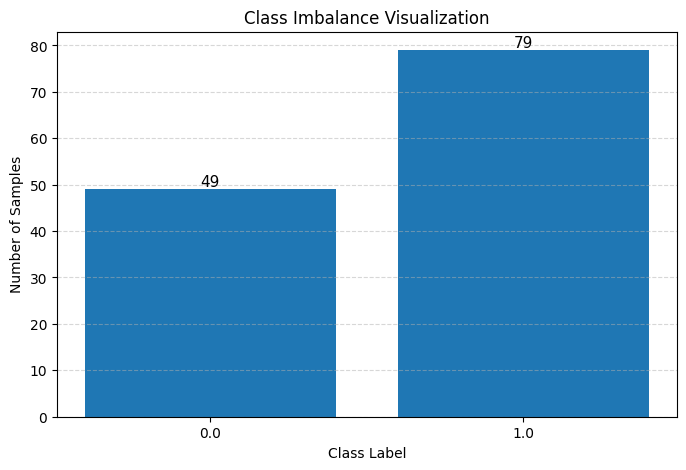

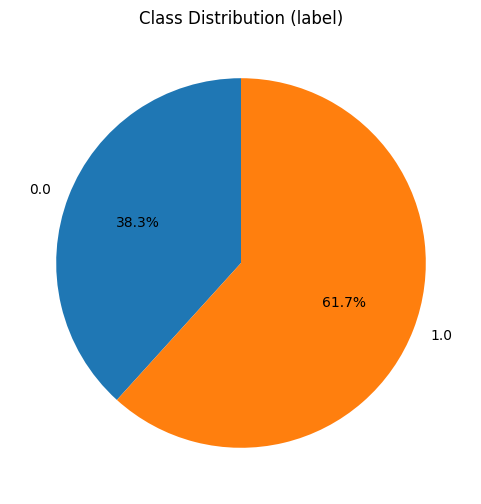


Imbalance Ratio: 1.61:1


In [4]:
# Load CSV
file_path = "TCGA_LUSC_Kaggle_Format.csv"
df = pd.read_csv(file_path)

# Class counts
class_counts = df["label"].value_counts().sort_index()

# Bar plot
plt.figure(figsize=(8, 5))

bars = plt.bar(
    class_counts.index.astype(str),
    class_counts.values
)

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        str(int(height)),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.xlabel("Class Label")
plt.ylabel("Number of Samples")
plt.title("Class Imbalance Visualization")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Pie chart
plt.figure(figsize=(6, 6))

plt.pie(
    class_counts.values,
    labels=class_counts.index.astype(str),
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Class Distribution (label)")
plt.show()

# Imbalance ratio
majority = class_counts.max()
minority = class_counts.min()
imbalance_ratio = majority / minority

print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")


#  Apply SMOTE and Create Graph

In [6]:
# Build feature tensors
df_lusc = pd.read_csv('TCGA_LUSC_Kaggle_Format.csv')
X = df_lusc.drop(columns=['sample_id', 'label']).values
y = df_lusc['label'].values

# Remove zero-variance features
var = X.var(axis=0)
X = X[:, var > 0]
X = np.nan_to_num(X)

# Standardize BEFORE SMOTE
X = StandardScaler().fit_transform(X)

print(f'Before SMOTE:')
print(f'  Class 0 (normal): {np.sum(y == 0)}')
print(f'  Class 1 (tumor) : {np.sum(y == 1)}')

# Apply SMOTE to balance classes
smote = SMOTE(random_state=42, k_neighbors=5)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f'\nAfter SMOTE:')
print(f'  Class 0 (normal): {np.sum(y_resampled == 0)}')
print(f'  Class 1 (tumor) : {np.sum(y_resampled == 1)}')

# Update X and y with resampled data
X = X_resampled
y = y_resampled

# Save SMOTE-balanced dataset
feature_columns = df_lusc.drop(columns=['sample_id', 'label']).columns[var > 0]

smote_df = pd.DataFrame(X_resampled, columns=feature_columns)
smote_df['label'] = y_resampled

smote_df.to_csv('LUSC_smote.csv', index=False)

print('\nSaved SMOTE-balanced dataset as LUSC_smote.csv')

# Split features into K groups
K = 4
gene_splits = np.array_split(np.arange(X.shape[1]), K)
X_list = [torch.tensor(X[:, idx], dtype=torch.float32) for idx in gene_splits]

# Patient kNN graph
k = 10
sim = cosine_similarity(X)
np.fill_diagonal(sim, 0)

edges = []
weights = []
for i in range(len(X)):
    topk_idx = np.argsort(sim[i])[-k:]
    for j in topk_idx:
        edges.append([i, j])
        weights.append(sim[i, j])

edge_index = torch.tensor(edges, dtype=torch.long).T
edge_weight = torch.tensor(weights, dtype=torch.float32)

print(f'\nPatient graph: {len(X)} nodes, {edge_index.size(1)} edges')


Before SMOTE:
  Class 0 (normal): 49
  Class 1 (tumor) : 502

After SMOTE:
  Class 0 (normal): 502
  Class 1 (tumor) : 502

Saved SMOTE-balanced dataset as LUSC_smote.csv

Patient graph: 1004 nodes, 10040 edges


#  Define FocalLoss

In [7]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.25):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
    
    def forward(self, logits, labels):
        p = torch.sigmoid(logits).view(-1)
        labels = labels.float().view(-1)
        ce = F.binary_cross_entropy_with_logits(logits.view(-1), labels, reduction='none')
        p_t = p * labels + (1 - p) * (1 - labels)
        alpha_t = self.alpha * labels + (1 - self.alpha) * (1 - labels)
        focal_weight = alpha_t * (1 - p_t) ** self.gamma
        loss = (focal_weight * ce).mean()
        return loss


#  Model Definition

In [8]:
def fuzzy_covering(adj, k=5):
    """
    Create fuzzy coverings from adjacency matrix.
    Returns list of k-nearest neighbors with their similarity weights.
    """
    coverings = []
    for i in range(adj.shape[0]):
        # Get top-k neighbors (excluding self)
        topk_idx = np.argsort(adj[i])[-k:]
        covering = [(int(topk_idx[j]), float(adj[i, topk_idx[j]])) for j in range(k)]
        coverings.append(covering)
    return coverings

def coverings_to_edge_index(coverings, return_weights=True):
    """
    Convert fuzzy coverings to PyTorch Geometric edge format.
    """
    edges = []
    weights = []
    
    for i, covering in enumerate(coverings):
        for neighbor, weight in covering:
            edges.append([i, neighbor])
            weights.append(weight)
    
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    
    if return_weights:
        edge_weight = torch.tensor(weights, dtype=torch.float32)
        return edge_index, edge_weight
    return edge_index

def build_fuzzy_graph(X, k=10):
    """
    Build fuzzy graph from feature matrix using cosine similarity.
    
    Args:
        X: Feature matrix [num_samples, num_features] (numpy array or torch tensor)
        k: Number of nearest neighbors for fuzzy covering
    
    Returns:
        edge_index: Edge indices [2, num_edges]
        edge_weight: Fuzzy membership weights [num_edges]
        coverings: List of fuzzy coverings
    """
    from sklearn.metrics.pairwise import cosine_similarity
    
    # Convert to numpy if torch tensor
    if isinstance(X, torch.Tensor):
        X = X.numpy()
    
    # Compute similarity matrix
    sim = cosine_similarity(X)
    np.fill_diagonal(sim, 0)
    
    # Create fuzzy coverings
    coverings = fuzzy_covering(sim, k=k)
    
    # Convert to edge format
    edge_index, edge_weight = coverings_to_edge_index(coverings)
    
    return edge_index, edge_weight, coverings

# Fuzzy Graph Convolution Layer 
class FuzzyCoverConv(MessagePassing):
    """
    Fuzzy covering-based graph convolution with learnable aggregation.
    """
    def __init__(self, in_channels, out_channels, heads=1, dropout=0.0):
        super().__init__(aggr='add', node_dim=0)
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.heads = heads
        self.dropout = dropout
        
        # Linear transformation
        self.lin = nn.Linear(in_channels, heads * out_channels, bias=False)
        
        # Attention mechanism for fuzzy weighting
        self.att_src = nn.Parameter(torch.Tensor(1, heads, out_channels))
        self.att_dst = nn.Parameter(torch.Tensor(1, heads, out_channels))
        
        self.bias = nn.Parameter(torch.Tensor(out_channels))
        
        self.reset_parameters()
    
    def reset_parameters(self):
        nn.init.xavier_uniform_(self.lin.weight)
        nn.init.xavier_uniform_(self.att_src)
        nn.init.xavier_uniform_(self.att_dst)
        nn.init.zeros_(self.bias)
    
    def forward(self, x, edge_index, edge_weight=None):
        """
        Args:
            x: Node features [num_nodes, in_channels]
            edge_index: Edge indices [2, num_edges]
            edge_weight: Fuzzy membership weights [num_edges]
        """
        # Linear transformation
        x = self.lin(x).view(-1, self.heads, self.out_channels)
        
        # Propagate messages
        out = self.propagate(edge_index, x=x, edge_weight=edge_weight)
        
        # Average over heads
        out = out.mean(dim=1)
        out = out + self.bias
        
        return out
    
    def message(self, x_i, x_j, edge_weight, index, ptr, size_i):
        """
        Compute messages with fuzzy attention.
        """
        # Compute attention scores
        alpha = (x_i * self.att_src).sum(dim=-1) + (x_j * self.att_dst).sum(dim=-1)
        alpha = F.leaky_relu(alpha, 0.2)
        
        # Incorporate fuzzy edge weights
        if edge_weight is not None:
            alpha = alpha * edge_weight.view(-1, 1)
        
        # Softmax normalization
        alpha = softmax(alpha, index, ptr, size_i)
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)
        
        # Weighted message
        return x_j * alpha.unsqueeze(-1)

# Fuzzy Graph Convolutional Network 
class FGC_GNN(nn.Module):
    """
    Fuzzy Graph Convolutional Network for multi-omics classification.
    Integrates fuzzy covering-based convolutions with attention mechanisms.
    
    This model is dataset-independent and can be used with any preprocessed data.
    """
    def __init__(self, in_dims, hidden_channels, out_channels, 
                 heads=4, dropout=0.3, use_fuzzy_conv=True):
        """
        Args:
            in_dims: List of input dimensions for each omics layer
            hidden_channels: Hidden dimension size
            out_channels: Number of output classes
            heads: Number of attention heads
            dropout: Dropout probability
            use_fuzzy_conv: Use FuzzyCoverConv if True, otherwise GCNConv
        """
        super().__init__()
        self.dropout_p = dropout
        self.use_fuzzy_conv = use_fuzzy_conv
        self.num_omics = len(in_dims)
        
        # Per-omics graph convolution branches
        if use_fuzzy_conv:
            self.omics_gcns = nn.ModuleList([
                FuzzyCoverConv(d, hidden_channels, heads=heads, dropout=dropout) 
                for d in in_dims
            ])
        else:
            from torch_geometric.nn import GCNConv
            self.omics_gcns = nn.ModuleList([
                GCNConv(d, hidden_channels, improved=True) 
                for d in in_dims
            ])
        
        # Residual projections
        self.res_proj = nn.ModuleList([
            nn.Linear(d, hidden_channels) for d in in_dims
        ])
        
        # Fuzzy attention gates per omics branch
        self.attn = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_channels, hidden_channels // 4),
                nn.ReLU(),
                nn.Linear(hidden_channels // 4, 1),
                nn.Sigmoid()
            ) for _ in range(self.num_omics)
        ])
        
        # Cross-omics attention
        self.cross_attn = nn.MultiheadAttention(
            hidden_channels, num_heads=heads, dropout=dropout, batch_first=True
        )
        
        # Fusion layers
        self.fc1 = nn.Linear(hidden_channels * self.num_omics, hidden_channels * 2)
        self.bn1 = nn.BatchNorm1d(hidden_channels * 2)
        
        self.fc2 = nn.Linear(hidden_channels * 2, hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        
        self.fc3 = nn.Linear(hidden_channels, out_channels)
        
        # Layer normalization for each omics
        self.layer_norms = nn.ModuleList([
            nn.LayerNorm(hidden_channels) for _ in range(self.num_omics)
        ])
    
    def forward(self, X_list, edge_index, edge_weight=None):
        """
        Args:
            X_list: List of feature tensors, one per omics [num_nodes, features_i]
            edge_index: Edge indices from fuzzy covering [2, num_edges]
            edge_weight: Fuzzy membership weights [num_edges]
        
        Returns:
            out: Classification logits [num_nodes, out_channels]
        """
        omics_embeddings = []
        
        # Process each omics layer
        for i, (gcn, res, attn, ln, X) in enumerate(
            zip(self.omics_gcns, self.res_proj, self.attn, self.layer_norms, X_list)
        ):
            # Graph convolution with fuzzy weights
            h = gcn(X, edge_index, edge_weight=edge_weight)
            
            # Residual connection
            h_res = res(X)
            h = h + h_res
            
            # Layer normalization
            h = ln(h)
            h = F.relu(h)
            h = F.dropout(h, p=self.dropout_p, training=self.training)
            
            # Fuzzy attention gate
            attn_weight = attn(h)
            h = attn_weight * h
            
            omics_embeddings.append(h)
        
        # Stack for cross-omics attention [num_nodes, num_omics, hidden_channels]
        omics_stack = torch.stack(omics_embeddings, dim=1)
        
        # Apply cross-omics attention
        attn_out, _ = self.cross_attn(omics_stack, omics_stack, omics_stack)
        
        # Residual connection for attention
        omics_stack = omics_stack + attn_out
        
        # Flatten for fusion
        h = omics_stack.reshape(omics_stack.size(0), -1)
        
        # Multi-layer fusion with residual
        h1 = F.relu(self.bn1(self.fc1(h)))
        h1 = F.dropout(h1, p=self.dropout_p, training=self.training)
        
        h2 = F.relu(self.bn2(self.fc2(h1)))
        h2 = F.dropout(h2, p=self.dropout_p, training=self.training)
        
        # Output layer
        out = self.fc3(h2)
        
        return out

# Define EarlyStopping Class

In [9]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4, mode='max'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.best_epoch = -1
        self.best_state = None
    
    def step(self, score, model, epoch):
        if self.best_score is None:
            self.best_score = score
            self.best_epoch = epoch
            self.best_state = copy.deepcopy(model.state_dict())
            return False
        
        improved = (
            (self.mode == 'max' and score > self.best_score + self.min_delta) or
            (self.mode == 'min' and score < self.best_score - self.min_delta)
        )
        
        if improved:
            self.best_score = score
            self.best_epoch = epoch
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter = 0
            return False
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True
            return False
    
    def restore_best(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


#  Define Utility Functions

In [10]:
def gpu_metrics(probs, labels, thr=None):
    """
    Compute metrics on GPU tensors.
    If thr is None, find optimal threshold using Youden's J.
    Returns: (auc, f1, acc, precision, recall, threshold)
    """
    probs_cpu = probs.cpu().numpy()
    labels_cpu = labels.cpu().numpy()
    
    if len(np.unique(labels_cpu)) < 2:
        return 0.5, 0.0, 0.0, 0.0, 0.0, 0.5
    
    auc = roc_auc_score(labels_cpu, probs_cpu)
    
    if thr is None:
        # Find optimal threshold using Youden's J
        from sklearn.metrics import roc_curve
        fpr, tpr, thresholds = roc_curve(labels_cpu, probs_cpu)
        j_scores = tpr - fpr
        best_idx = np.argmax(j_scores)
        thr = thresholds[best_idx]
    
    preds = (probs_cpu >= thr).astype(int)
    f1 = f1_score(labels_cpu, preds, zero_division=0)
    acc = accuracy_score(labels_cpu, preds)
    
    from sklearn.metrics import precision_score, recall_score
    prec = precision_score(labels_cpu, preds, zero_division=0)
    rec = recall_score(labels_cpu, preds, zero_division=0)
    
    return auc, f1, acc, prec, rec, thr


#  Setup Device and Output Directory

In [11]:
DATASET = 'LUSC'
OUT_DIR = 'LUSC_outputs'
os.makedirs(OUT_DIR, exist_ok=True)

IS_CUDA = torch.cuda.is_available()
device = torch.device('cuda' if IS_CUDA else 'cpu')
print(f'Device: {device}')

# Move data to GPU
X_list_gpu = [x.to(device) for x in X_list]
edge_idx_gpu = edge_index.to(device)
edge_wt_gpu = edge_weight.to(device)
y_gpu = torch.tensor(y, dtype=torch.float32, device=device)

in_dims_cv = [x.size(1) for x in X_list_gpu]
print(f'Feature group dimensions: {in_dims_cv}')


Device: cuda
Feature group dimensions: [13815, 13815, 13815, 13814]


#  Define Hyperparameter Grid

In [12]:
PARAM_GRID = {
    'hidden_channels': [128, 256, 512],
    'lr'             : [1e-3, 2e-4],
    'weight_decay'   : [1e-4, 1e-5],
    'dropout'        : [0.3, 0.5],
    'focal_gamma'    : [1, 2],
    'focal_alpha'    : [0.5, 0.75],
    'epochs'         : [400, 700, 1000],
}

# Generate all combinations
param_combinations = list(itertools.product(*PARAM_GRID.values()))
print(f'Total hyperparameter combinations: {len(param_combinations)}')

Total hyperparameter combinations: 288


#  Train/Test Split (80/20)

In [13]:
train_idx_np, test_idx_np, y_train_np, y_test_np = train_test_split(
    np.arange(len(y)),
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Train samples: {len(train_idx_np)} ({len(train_idx_np)/len(y)*100:.1f}%)')
print(f'Test samples: {len(test_idx_np)} ({len(test_idx_np)/len(y)*100:.1f}%)')


Train samples: 803 (80.0%)
Test samples: 201 (20.0%)


#  Cross-Validation and Hyperparameter Search

In [14]:
N_FOLDS = 5
EVAL_EVERY = 10
MAX_EPOCHS_CV = 200

cv_results = []
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

for hp_idx, hp_tuple in enumerate(param_combinations):
    hp_dict = dict(zip(PARAM_GRID.keys(), hp_tuple))
    
    print(f'\n[{hp_idx+1}/{len(param_combinations)}] Testing HP: {hp_dict}')
    
    fold_auc = []
    fold_f1 = []
    fold_acc = []
    fold_thr = []
    
    for fold, (train_cv_idx, val_cv_idx) in enumerate(skf.split(train_idx_np, y_train_np)):
        # Map to global indices
        global_train = train_idx_np[train_cv_idx]
        global_val = train_idx_np[val_cv_idx]
        
        # Convert to GPU tensors
        train_t = torch.tensor(global_train, dtype=torch.long, device=device)
        val_t = torch.tensor(global_val, dtype=torch.long, device=device)
        
        y_tr = y_gpu[train_t]
        y_va = y_gpu[val_t]
        
        # Build model
        model = FGC_GNN(
            in_dims=in_dims_cv,
            hidden_channels=hp_dict['hidden_channels'],
            out_channels=1,
            dropout=hp_dict['dropout'],
        ).to(device)
        
        optimizer = optim.AdamW(
            model.parameters(),
            lr=hp_dict['lr'],
            weight_decay=hp_dict['weight_decay']
        )
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=hp_dict['epochs']
        )
        criterion = FocalLoss(
            gamma=hp_dict['focal_gamma'],
            alpha=hp_dict['focal_alpha']
        )
        amp_scaler = torch.amp.GradScaler('cuda', enabled=IS_CUDA)
        
        # Training loop
        for epoch in range(hp_dict['epochs']):
            model.train()
            optimizer.zero_grad(set_to_none=True)
            
            with torch.amp.autocast('cuda', enabled=IS_CUDA):
                out_all = model(X_list_gpu, edge_idx_gpu, edge_wt_gpu)
            
            loss = criterion(out_all[train_t], y_tr)
            amp_scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            amp_scaler.step(optimizer)
            amp_scaler.update()
            scheduler.step()
        
        # Final evaluation
        model.eval()
        with torch.inference_mode():
            out_final = model(X_list_gpu, edge_idx_gpu, edge_wt_gpu)
            val_probs = out_final[val_t].view(-1)
        
        auc, f1, acc, prec, rec, thr = gpu_metrics(val_probs, y_va, thr=None)
        
        fold_auc.append(auc)
        fold_f1.append(f1)
        fold_acc.append(acc)
        fold_thr.append(thr)
        
        print(f'  Fold {fold+1}: AUC={auc:.4f}, F1={f1:.4f}, Acc={acc:.4f}')
    
    # Aggregate fold results
    cv_results.append({
        **hp_dict,
        'mean_auc': np.mean(fold_auc),
        'std_auc': np.std(fold_auc),
        'mean_f1': np.mean(fold_f1),
        'mean_acc': np.mean(fold_acc),
        'mean_thr': np.mean(fold_thr),
    })

# Create DataFrame and save
cv_df = pd.DataFrame(cv_results)
cv_df = cv_df.sort_values('mean_auc', ascending=False).reset_index(drop=True)

cv_csv = os.path.join(OUT_DIR, f'FGC_GNN_{DATASET}_cv_results.csv')
cv_df.to_csv(cv_csv, index=False)

print('\n' + '='*70)
print('TOP 5 HYPERPARAMETER CONFIGURATIONS')
print('='*70)
display_cols = ['hidden_channels', 'dropout', 'lr', 'mean_auc', 'std_auc', 'mean_f1', 'mean_acc']
print(cv_df[display_cols].head(5).to_string(index=True))
print(f'\nCV results → {cv_csv}')



[1/288] Testing HP: {'hidden_channels': 128, 'lr': 0.001, 'weight_decay': 0.0001, 'dropout': 0.3, 'focal_gamma': 1, 'focal_alpha': 0.5, 'epochs': 400}
  Fold 1: AUC=1.0000, F1=1.0000, Acc=1.0000
  Fold 2: AUC=0.9875, F1=0.9939, Acc=0.9938
  Fold 3: AUC=1.0000, F1=1.0000, Acc=1.0000
  Fold 4: AUC=0.9897, F1=0.9937, Acc=0.9938
  Fold 5: AUC=1.0000, F1=1.0000, Acc=1.0000

[2/288] Testing HP: {'hidden_channels': 128, 'lr': 0.001, 'weight_decay': 0.0001, 'dropout': 0.3, 'focal_gamma': 1, 'focal_alpha': 0.5, 'epochs': 700}
  Fold 1: AUC=1.0000, F1=1.0000, Acc=1.0000
  Fold 2: AUC=0.9892, F1=0.9939, Acc=0.9938
  Fold 3: AUC=1.0000, F1=1.0000, Acc=1.0000
  Fold 4: AUC=0.9948, F1=0.9937, Acc=0.9938
  Fold 5: AUC=1.0000, F1=1.0000, Acc=1.0000

[3/288] Testing HP: {'hidden_channels': 128, 'lr': 0.001, 'weight_decay': 0.0001, 'dropout': 0.3, 'focal_gamma': 1, 'focal_alpha': 0.5, 'epochs': 1000}
  Fold 1: AUC=1.0000, F1=1.0000, Acc=1.0000
  Fold 2: AUC=0.9883, F1=0.9939, Acc=0.9938
  Fold 3: AUC=1

#  Extract Best Hyperparameters

In [15]:
best_row = cv_df.iloc[0]
best_hp = {k: best_row[k] for k in PARAM_GRID.keys()}

# Enforce correct Python types
best_hp['hidden_channels'] = int(best_hp['hidden_channels'])
best_hp['epochs'] = int(best_hp['epochs'])
best_hp['focal_gamma'] = float(best_hp['focal_gamma'])
best_hp['focal_alpha'] = float(best_hp['focal_alpha'])
best_hp['lr'] = float(best_hp['lr'])
best_hp['weight_decay'] = float(best_hp['weight_decay'])
best_hp['dropout'] = float(best_hp['dropout'])
BEST_THR = float(best_row['mean_thr'])

print(f'\n{"="*60}')
print(f'  Best hyperparameters  '
      f'(CV AUC = {best_row["mean_auc"]:.4f} ± {best_row["std_auc"]:.4f}  '
      f'F1 = {best_row["mean_f1"]:.4f}  Acc = {best_row["mean_acc"]:.4f})')
print(f'{"="*60}')
for k, v in best_hp.items():
    print(f'  {k:<20}: {v}')
print(f'  {"optimal_threshold":<20}: {BEST_THR:.4f}  ← Youden\'s J from CV')
print(f'{"="*60}\n')


  Best hyperparameters  (CV AUC = 0.9998 ± 0.0004  F1 = 0.9987  Acc = 0.9988)
  hidden_channels     : 512
  lr                  : 0.001
  weight_decay        : 0.0001
  dropout             : 0.3
  focal_gamma         : 2.0
  focal_alpha         : 0.75
  epochs              : 700
  optimal_threshold   : -1.6125  ← Youden's J from CV



#  Final Training 

In [18]:
ES_PATIENCE = 40
ES_MIN_DELTA = 1e-4
EPOCHS = best_hp['epochs']


local = np.arange(len(train_idx_np))
local_tr, local_val = train_test_split(
    local, test_size=0.20, random_state=42, stratify=y_train_np
)

# GPU index tensors
global_tr_es = torch.tensor(train_idx_np[local_tr], dtype=torch.long, device=device)
global_val_es = torch.tensor(train_idx_np[local_val], dtype=torch.long, device=device)
test_t = torch.tensor(test_idx_np, dtype=torch.long, device=device)

y_tr_gpu = y_gpu[global_tr_es]
y_val_gpu = y_gpu[global_val_es]
y_te_gpu = y_gpu[test_t]

print(f'  ES-train : {len(global_tr_es)} patients  (~72% of total)')
print(f'  ES-val   : {len(global_val_es)} patients  (ES monitor — never tested)')
print(f'  Test     : {len(test_t)} patients  (locked until the end)\n')

# Build model
final_model = FGC_GNN(
    in_dims=in_dims_cv,
    hidden_channels=best_hp['hidden_channels'],
    out_channels=1,
    dropout=best_hp['dropout'],
).to(device)


# torch.compile — graceful Triton fallback
if IS_CUDA and hasattr(torch, 'compile'):
    try:
        final_model = torch.compile(final_model, mode='reduce-overhead', fullgraph=False)
        print('  torch.compile ✔')
    except Exception:
        print('  torch.compile skipped → eager mode')

final_optimizer = optim.AdamW(
    final_model.parameters(),
    lr=best_hp['lr'],
    weight_decay=best_hp['weight_decay']
)
final_scheduler = optim.lr_scheduler.CosineAnnealingLR(final_optimizer, T_max=EPOCHS)
final_criterion = FocalLoss(gamma=best_hp['focal_gamma'], alpha=best_hp['focal_alpha'])
amp_scaler = torch.amp.GradScaler('cuda', enabled=IS_CUDA)
es = EarlyStopping(patience=ES_PATIENCE, min_delta=ES_MIN_DELTA, mode='max')

epoch_log = []
stopped_at = EPOCHS

print(f'Training final model | {DATASET} | {EPOCHS} epochs | device: {device}\n')

pbar = tqdm(range(EPOCHS), desc=f'Final Training ({DATASET})', unit='ep', dynamic_ncols=True)

for epoch in pbar:
    # TRAIN
    final_model.train()
    final_optimizer.zero_grad(set_to_none=True)
    with torch.amp.autocast('cuda', enabled=IS_CUDA):
        out_all = final_model(X_list_gpu, edge_idx_gpu, edge_wt_gpu)
    loss = final_criterion(out_all[global_tr_es], y_tr_gpu)
    amp_scaler.scale(loss).backward()
    torch.nn.utils.clip_grad_norm_(final_model.parameters(), 2.0)
    amp_scaler.step(final_optimizer)
    amp_scaler.update()
    final_scheduler.step()
    loss_val = loss.item()
    
    # EVAL — single forward pass, three slices
    if (epoch + 1) % EVAL_EVERY == 0 or epoch == EPOCHS - 1:
        with torch.inference_mode():
            out_e = final_model(X_list_gpu, edge_idx_gpu, edge_wt_gpu)
            tr_probs = out_e[global_tr_es].view(-1)
            ev_probs = out_e[global_val_es].view(-1)
            te_probs = out_e[test_t].view(-1)
        
        tr_auc, tr_f1, tr_acc, tr_pr, tr_rc, _ = gpu_metrics(tr_probs, y_tr_gpu, thr=None)
        ev_auc, ev_f1, ev_acc, ev_pr, ev_rc, ev_thr = gpu_metrics(ev_probs, y_val_gpu, thr=None)
        te_auc, te_f1, te_acc, te_pr, te_rc, _ = gpu_metrics(te_probs, y_te_gpu, thr=BEST_THR)
        
        epoch_log.append({
            'Epoch': epoch + 1, 'Loss': loss_val,
            'Train_AUC': tr_auc, 'Train_F1': tr_f1, 'Train_Acc': tr_acc,
            'Val_AUC': ev_auc, 'Val_F1': ev_f1, 'Val_Acc': ev_acc,
            'Test_AUC': te_auc, 'Test_F1': te_f1, 'Test_Acc': te_acc,
        })
        
        pbar.set_postfix({
            'loss': f'{loss_val:.4f}',
            'val_AUC': f'{ev_auc:.4f}',
            'te_AUC': f'{te_auc:.4f}',
            'te_F1': f'{te_f1:.4f}',
        })
        
        # ES monitors val AUC — NOT train AUC
        if es.step(ev_auc, final_model, epoch):
            stopped_at = epoch + 1
            print(f'\n  ⏹  Early stopping at epoch {stopped_at}  '
                  f'(best val AUC = {es.best_score:.4f} '
                  f'@ epoch {es.best_epoch + 1})')
            break

es.restore_best(final_model)
print(f'   Best checkpoint restored from epoch {es.best_epoch + 1}')


  ES-train : 642 patients  (~72% of total)
  ES-val   : 161 patients  (ES monitor — never tested)
  Test     : 201 patients  (locked until the end)

  torch.compile ✔
Training final model | LUSC | 700 epochs | device: cuda



Final Training (LUSC):  58%|▌| 409/700 [00:28<00:20, 14.36ep/s, loss=0.0000, val_AUC=1.0000, te_AUC=1.0000, te_F1=1.000


  ⏹  Early stopping at epoch 410  (best val AUC = 1.0000 @ epoch 10)
  ✔  Best checkpoint restored from epoch 10


#  Final Test Evaluation

In [19]:

final_model.eval()
with torch.inference_mode():
    out_final = final_model(X_list_gpu, edge_idx_gpu, edge_wt_gpu)
    te_probs = out_final[test_t].view(-1)

final_auc, final_f1, final_acc, final_prec, final_rec, _ = gpu_metrics(
    te_probs, y_te_gpu, thr=BEST_THR
)

# Save artifacts
ckpt_path = os.path.join(OUT_DIR, f'FGC_GNN_{DATASET}_best_final.pt')
torch.save(final_model.state_dict(), ckpt_path)

epoch_csv = os.path.join(OUT_DIR, f'FGC_GNN_{DATASET}_epoch_metrics.csv')
pd.DataFrame(epoch_log).to_csv(epoch_csv, index=False)

pred_csv = os.path.join(OUT_DIR, f'FGC_GNN_{DATASET}_test_predictions.csv')
pd.DataFrame({
    'sample_index': test_idx_np,
    'y_true': y_te_gpu.cpu().numpy(),
    'y_prob': te_probs.cpu().numpy(),
    'y_pred': (te_probs >= BEST_THR).long().cpu().numpy(),
}).to_csv(pred_csv, index=False)

summary_csv = os.path.join(OUT_DIR, f'FGC_GNN_{DATASET}_summary.csv')
pd.DataFrame([{
    'Dataset': DATASET,
    'AUC': final_auc,
    'F1': final_f1,
    'Accuracy': final_acc,
    'Precision': final_prec,
    'Recall': final_rec,
    'Threshold': BEST_THR,
    'Stopped_Epoch': stopped_at,
    'Best_Val_AUC': es.best_score,
    'Best_Checkpoint_Epoch': es.best_epoch + 1,
    'CV_best_mean_AUC': float(best_row['mean_auc']),
    'CV_best_std_AUC': float(best_row['std_auc']),
    'CV_best_mean_F1': float(best_row['mean_f1']),
    'CV_best_mean_Acc': float(best_row['mean_acc']),
    'CV_best_mean_thr': float(best_row['mean_thr']),
    **{f'HP_{k}': v for k, v in best_hp.items()},
}]).to_csv(summary_csv, index=False)

# Final print
print(f'\n{"="*55}')
print(f'  FINAL TEST RESULTS — {DATASET}')
print(f'{"="*55}')
print(f'  AUC       : {final_auc:.4f}')
print(f'  F1 Score  : {final_f1:.4f}')
print(f'  Accuracy  : {final_acc:.4f}')
print(f'  Precision : {final_prec:.4f}')
print(f'  Recall    : {final_rec:.4f}')
print(f'  Threshold : {BEST_THR:.4f}  (Youden\'s J from CV val)')
print(f'{"─"*55}')
print(f'  Stopped at epoch          : {stopped_at}')
print(f'  Best checkpoint epoch     : {es.best_epoch + 1}')
print(f'  Best ES-val AUC           : {es.best_score:.4f}')
print(f'{"─"*55}')
print(f'  Best HPs from CV:')
for k, v in best_hp.items():
    print(f'    {k:<20}: {v}')
print(f'{"="*55}')
print(f'\nOutputs saved to ./{OUT_DIR}/:')
for p in [cv_csv, epoch_csv, pred_csv, summary_csv, ckpt_path]:
    print(f'  {os.path.basename(p)}')


  FINAL TEST RESULTS — LUSC
  AUC       : 1.0000
  F1 Score  : 0.9950
  Accuracy  : 0.9950
  Precision : 1.0000
  Recall    : 0.9900
  Threshold : -1.6125  (Youden's J from CV val)
───────────────────────────────────────────────────────
  Stopped at epoch          : 410
  Best checkpoint epoch     : 10
  Best ES-val AUC           : 1.0000
───────────────────────────────────────────────────────
  Best HPs from CV:
    hidden_channels     : 512
    lr                  : 0.001
    weight_decay        : 0.0001
    dropout             : 0.3
    focal_gamma         : 2.0
    focal_alpha         : 0.75
    epochs              : 700

Outputs saved to ./LUSC_outputs/:
  FGC_GNN_LUSC_cv_results.csv
  FGC_GNN_LUSC_epoch_metrics.csv
  FGC_GNN_LUSC_test_predictions.csv
  FGC_GNN_LUSC_summary.csv
  FGC_GNN_LUSC_best_final.pt
